<a href="https://colab.research.google.com/github/linyuan-zhang/Macroeconomics_Visualizations/blob/main/The_Solow_Model_on_Japan_Economic_Growth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project is based on an Excel project for Professor Erin Cottle Hunt's ECON 314 Macroeconomic Theory.

This project uses macroeconomic data from FRED. Using counterfactual analysis and simulation, this project demonstrates that in the Solow model, total factor productivity is the element that mainly drives (Japan) economic growth trend, and provides visualizations. It also incorporates a very brief economic history of post-World-War-II Japan.

There is a tutorial in R and a tutorial in Python, giving the same computations and visualizations. The only exception is part of Section IV, a shooting and binary search algorithm, which searches for a parameter that makes two curves converge. This algorithm is included in the Python version only.

The R version requires data wrangling and data visualization skills from MATH 141 Intro Statistics (which is a required course for the Quantitative Economics major), as well as understanding of recursive functions and loops. For Quantitative Economics majors, it may be an easier read. There is a qmd file and a knitted html file.

The Python version requires Python knowledge that is not taught in CSCI 121 Computer Science I. Therefore, there is more scaffolding. Nevertheless, when it comes to computation, Python is a language far more versatile than R, and it runs faster. In addition, to my knowledge, more economic coding is done in Python than in R.



**Table of Contents**

Section I. Comparative Analysis of Japan and United States Post World War II Economic Growth

Section II. The Solow Model of Japan Post-World-War-II Economic Growth

Section III. Counterfactual Solow Models of Japan Post World War II Economic Growth

Section IV. What Post-1970 TFP Growth Rate Japan Needs to Have to Make Its Real GDP per Capita Converge to That of USA

Load Python libraries and functions.

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from google.colab import drive
from itertools import accumulate

# Section I. Comparative Analysis of Japan and United States Post World War II Economic Growth

We choose Real GDP per Capita to be the indicator of economic growth.

## Data

We use Real GDP and Population to calculate Real GDP per Capita.

### Real GDP

There are multiple Real GDP data for both Japan and United States in the FRED database. We look at them and compare.

The data series below are Real GDP at Constant National Prices for United States and Real GDP at Constant National Prices for Japan. Both are provided by Groningen Growth and Development Centre, and that they are provided by the same organization makes the data good for cross-country comparative analysis. The data series are annual.

The series' names in the FRED database are `RGDPNAUSA666NRUG` and `RGDPNAJPA666NRUG`, respectively.

To obtain the URLs from which to load the CSV format data, find the page of the data series, find "Download", find "CSV (data)", and copy the link address for "CSV (data)".

When loading, set the end year of the data series to be `2099` so that the data is always up-to-date.

The current data series end at `2023`.

In [99]:
usa_rgdp_groningen = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23e1e9f0&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=RGDPNAUSA666NRUG&scale=left&cosd=1950-01-01&coed=2099-12-31&line_color=%234572a7&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Annual&fam=avg&fgst=lin&fgsnd=2099-12-31&line_index=1&transformation=lin&nd=1950-01-01")

In [100]:
jpa_rgdp_groningen = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=off&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=RGDPNAJPA666NRUG&scale=left&cosd=1950-01-01&coed=2099-12-31&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Annual&fam=avg&fgst=lin&fgsnd=2099-12-31&line_index=1&transformation=lin&nd=1950-01-01")

If we want to have data series that end at some year closer to the present (`2026`), use the data series Real Gross Domestic Product and Real Gross Domestic Product for Japan. The former is provided by U.S. Bureau of Economic Analysis, and the latter by Cabinet Office of Japan. The data series are both seasonal.

The series' names in the FRED database are `GDPC1` and `JPNRGDPEXP`, respectively.

This Japan data series starts at `1994`, and this USA data series starts at `1994`. When we `merge` two datasets containing different series, the `merge` function in `pandas`, when `how` set to `inner` and `on` set to `observation_date`, keeps only entries with the same date. Therefore, if we `merge` the USA series and the Japan series, the start year will be `1994` and the end year will be `2026`.

In [101]:
usa_rgdp_bureau = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=GDPC1&scale=left&cosd=1947-01-01&coed=2099-12-31&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Quarterly&fam=avg&fgst=lin&fgsnd=2099-12-31&line_index=1&transformation=lin&nd=1947-01-01")

In [102]:
jpa_rgdp_cabinet = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=off&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=JPNRGDPEXP&scale=left&cosd=1994-01-01&coed=2099-12-31&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Quarterly&fam=avg&fgst=lin&fgsnd=2099-12-31&line_index=1&transformation=lin&nd=1994-01-01")

To convert the above two data series from seasonal to annual, use the following code. Or, we can just `inner` `merge` the two data series with some annual data series.

In [103]:
usa_rgdp_bureau["observation_date"] = pd.to_datetime(usa_rgdp_bureau["observation_date"])
usa_rgdp_bureau["month"] = usa_rgdp_bureau["observation_date"].dt.month
usa_rgdp_bureau = usa_rgdp_bureau.query("month == 1")
usa_rgdp_bureau.pop("month");

In [104]:
jpa_rgdp_cabinet["observation_date"] = pd.to_datetime(jpa_rgdp_cabinet["observation_date"])
jpa_rgdp_cabinet["month"] = jpa_rgdp_cabinet["observation_date"].dt.month
jpa_rgdp_cabinet = jpa_rgdp_cabinet.query("month == 1")
jpa_rgdp_cabinet.pop("month");

### Population

The following data series are from Groningen Growth and Development Centre and end at `2023`.

The series' names in the FRED database are `POPTTLUSA148NRUG` (or Population for United States) and `POPTTLJPA148NRUG` (or Population for Japan), respectively.

In [105]:
usa_pop_groningen = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=POPTTLUSA148NRUG&scale=left&cosd=1950-01-01&coed=2099-12-31&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Annual&fam=avg&fgst=lin&fgsnd=2099-12-31&line_index=1&transformation=lin&nd=1950-01-01")

In [106]:
jpa_pop_groningen = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=off&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=POPTTLJPA148NRUG&scale=left&cosd=1950-01-01&coed=2099-12-31&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Annual&fam=avg&fgst=lin&fgsnd=2099-12-31&line_index=1&transformation=lin&nd=1950-01-01")

The following data series are from World Bank. They start at `1960` and end at `2025`.

The series' names in the FRED database are `POPTOTUSA647NWDB` (or Population, Total for United States) and `POPTOTJPA647NWDB` (or Population, Total for Japan), respectively.

In [107]:
usa_pop_world_bank = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=POPTOTUSA647NWDB&scale=left&cosd=1960-01-01&coed=2099-12-31&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Annual&fam=avg&fgst=lin&fgsnd=2099-12-31&line_index=1&transformation=lin&nd=1960-01-01")

In [108]:
jpa_pop_world_bank = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=off&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=POPTOTJPA647NWDB&scale=left&cosd=1960-01-01&coed=2025-01-01&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Annual&fam=avg&fgst=lin&fgsnd=2099-12-31&line_index=1&transformation=lin&nd=1960-01-01")

### Data Choice

We use the Groningen data series for comparative analysis, both because we want to analyse the growth trends after World War II and these data starts right after World War II, and because they are from the same organization and are therefore more consistent with each other.

### Data Cleaning

To document the relationship between Year and Real GDP per Capita of USA and Japan, we `inner` `merge` all requisite data into one dataset.

In [109]:
df_1 = pd.merge(usa_rgdp_groningen, jpa_rgdp_groningen, on = "observation_date", how = "inner")
df_1 = pd.merge(df_1, usa_pop_groningen, on = "observation_date", how = "inner")
df_1 = pd.merge(df_1, jpa_pop_groningen, on = "observation_date", how = "inner")

Rename the columns for better comprehension.

In [110]:
df_1.columns = ["year", "rgdp_usa", "rgdp_jpa", "pop_usa", "pop_jpa"]

Because we want to have an annual data series, reformat `year` into year-only-format.

In [111]:
df_1["year"] = pd.to_datetime(df_1["year"])
df_1["year"] = df_1["year"].dt.year

### Calculation

Calculate Real GDP per Capita.

In [112]:
df_1["rgdpc_usa"] = df_1["rgdp_usa"] / df_1["pop_usa"]
df_1["rgdpc_jpa"] = df_1["rgdp_jpa"] / df_1["pop_jpa"]

Calculate the ratio between Real GDP per Capita of Japan and Real GDP per Capita of United States.

In [113]:
df_1["ratio"] = df_1["rgdpc_jpa"] / df_1["rgdpc_usa"]

## Comparative Analysis Plots

A common choice for Python data visualization is to use the library `matplotlib`. Nevertheless, according to recommendation by Professor Erin Cottle Hunt, there is a prettier, more higher-level data visualization library, `seaborn`.

We use `seaborn` for our data visualization.

While `matplotlib` (as well as R's famous `ggplot2`) works better with wide format data, `seaborn` works better with long format data.

So we convert our data frame `df_1`'s `rgdpc` part from wide format to long format.

In [114]:
df_1_rgdpc_long = df_1.melt(
    id_vars = ["year"],
    value_vars = ["rgdpc_usa", "rgdpc_jpa"],
    var_name = "Country",
    value_name = "rgdpc",
)

Print `df_1_rgdpc_long` so we understand what long format data looks like.

In [115]:
print(df_1_rgdpc_long)

     year    Country         rgdpc
0    1950  rgdpc_usa  17555.889063
1    1951  rgdpc_usa  18651.324961
2    1952  rgdpc_usa  19081.249486
3    1953  rgdpc_usa  19648.883805
4    1954  rgdpc_usa  19197.483403
..    ...        ...           ...
143  2019  rgdpc_jpa  43195.366066
144  2020  rgdpc_jpa  41533.450622
145  2021  rgdpc_jpa  42808.321444
146  2022  rgdpc_jpa  43452.745940
147  2023  rgdpc_jpa  44404.932448

[148 rows x 3 columns]


The data frame `df_1_rgdpc_long` is primarily used for visualation. In visualization, we should show legends (i.e. "USA", "Japan") for different trend lines.

So we replace the values for `Country` with clearer legend labels.

In [116]:
df_1_rgdpc_long["Country"] = df_1_rgdpc_long["Country"].map({"rgdpc_usa": "USA", "rgdpc_jpa": "Japan"})

In `seaborn`, we can use both `seaborn`'s color palettes and `matplotlib`'s color palettes.

[View `seaborn`'s color palettes here.](https://seaborn.pydata.org/tutorial/color_palettes.html)

[View `matplotlib`'s color palettes here.](https://matplotlib.org/stable/users/explain/colors/colormaps.html)

Because the main visualizations we want to do in this project are trend lines, and because we want to denote each trend line with one distinct color, we should choose a discrete color palette rather than a continous color palette. We will define a customized color palette in each plot.

We want to show grid lines to better know the variables' values. So we choose `whitegrid` for `style`.

Because we are doing visualization in Google Colab, an environment similar to Jupyter Notebook, we choose `notebook` for `context`.

For `font`, we choose `sans-serif` because it is less cognitively heavy than `serif`.

Set the global environment for all of our plots.

In [117]:
sns.set_theme(
    context = "notebook",
    style = "whitegrid",
    font = "sans-serif",
    rc = {
        "grid.linestyle": ":",
        "axes.edgecolor": "black",
    },
)

Plot Real GDP per Capita of USA and Japan.

We use log scale to better exhibit Real GDP per Capita growth rate.

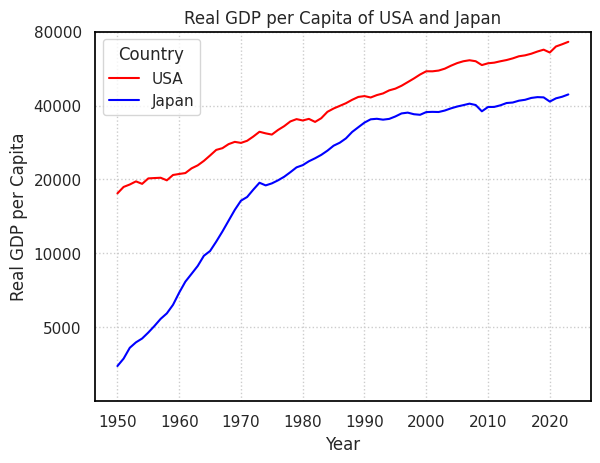

In [118]:
ax = sns.lineplot(
    data = df_1_rgdpc_long,
    x = "year",
    y = "rgdpc",
    hue = "Country",
    palette = {"USA": "red", "Japan": "blue"}
)

ax.set(
    title = "Real GDP per Capita of USA and Japan",
    xlabel = "Year",
    ylabel = "Real GDP per Capita",
)

ax.set_yscale("log")
ax.set_ylim(2500, 80000)
ax.set_yticks([5000, 10000, 20000, 40000, 80000])
ax.get_yaxis().set_major_formatter(ticker.ScalarFormatter())

plt.show()

Plot the ratio between Real GDP per Capita of Japan and Real GDP per Capita of United States.

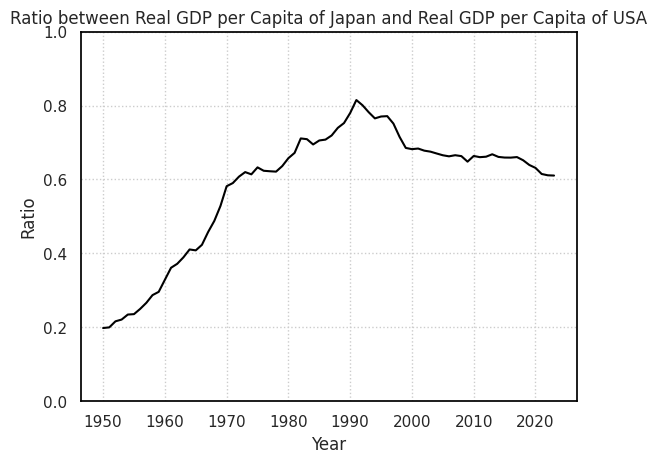

In [119]:
ax = sns.lineplot(
    data = df_1,
    x = "year",
    y = "ratio",
    color = "black",
)

ax.set(
    title = "Ratio between Real GDP per Capita of Japan and Real GDP per Capita of USA",
    xlabel = "Year",
    ylabel = "Ratio",
)

ax.set_ylim(0, 1)

plt.show()

## Conclusion

Japan's Real GDP per Capita is always less than USA's Real GDP per Capita.

From 1950 to 1970, Japan experienced a post-WWII economic bloom, and its Real GDP per Capita grew very fast, faster than that of USA.

From 1970 to 1990, Japan experienced the Bubble Economy, and its Real GDP per Capita grew still faster than that of USA.

In 1990, Japan's Economic Bubble burst. As a result, its Real GDP per Capita growth slowed down significantly. Its Real GDP per Capita grew slower than that of USA.

We see some parellel kinks in both USA and Japan's Real GDP per Capita post-millennium, especially one in 2008 (Financial Crisis) and 2020 (Covid). These parellel kinks are because of the globalization of world economy.

From 1950 to 1990, the ratio of Japan's Real GDP per Capita to USA's Real GDP per Capita grew. It dropped in the 1990s, when Japan's Bubble burst. It is slowly but steadily declining from 2000 onwards, indicating that USA is growing faster than Japan post-millennium.

# Section II. The Solow Model of Japan Post-World-War-II Economic Growth

In the Solow Model, a country's economic growth is propelled by Total Factor Productivity ($A$), Capital ($K$), and Labor (which is related to but is not the same as Population) ($N$). Growth is also influenced by Savings Rate, and Government Spending as a Fraction of Output.

In this section, we look at the trends for Population Growth Rate (which is similar to but is not the same as Labor Growth Rate) ($x$), Savings Rate ($s$), Government Spending as a Fraction of Output ($\psi$), and TFP Growth Rate ($\phi$) of post-WWII Japan, and predict Japan's Output per Capita based on the Solow Model.

## Data

The data for $x$, $s$, $\psi$, and $\phi$ are provided by Professor Erin Cottle Hunt in an Excel spreadsheet.

In the Excel file, we delete the second row, which has no observation.

To call that Excel file in Google Colab, we first put the Excel file in our Google Drive.

We should not attempt to save the Excel file as a Google Sheet. It is much more complicated to read a Google Sheet in Python than to read an Excel spreadsheet.

Next, we import the library by which we can call files in our Google Drive.

In [120]:
from google.colab import drive

Connect to our Google Drive.

In [121]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Read the file.

In [122]:
model_inputs = pd.read_excel("/content/drive/MyDrive/Model_Inputs.xlsx")

### Data Cleaning

Rename the columns.

In [123]:
model_inputs.columns = ["year", "x", "s", "psi", "phi"]

`merge` `model_inputs` with the Real GDP data for Section I.

In [124]:
df_2 = pd.merge(df_1, model_inputs, on = "year", how = "inner")

## Exploratory Data Analysis

We make the following plots to exhibit trends in $x$, $s$, $\psi$, and $\phi$ of Japan post WWII.

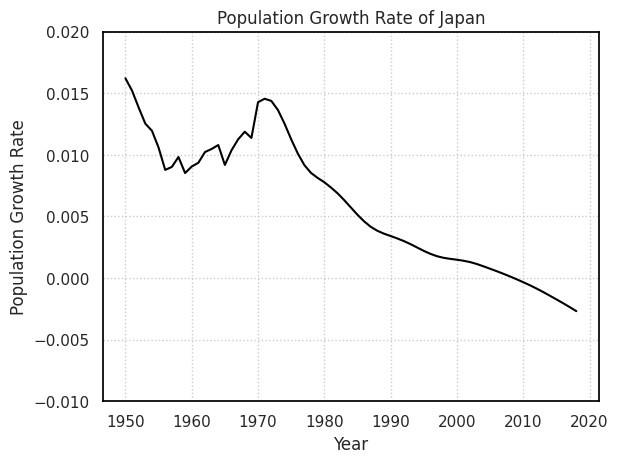

In [125]:
ax = sns.lineplot(
    data = df_2,
    x = "year",
    y = "x",
    color = "black",
)

ax.set(
    title = "Population Growth Rate of Japan",
    xlabel = "Year",
    ylabel = "Population Growth Rate",
)

ax.set_ylim(-0.01, 0.02)

plt.show()

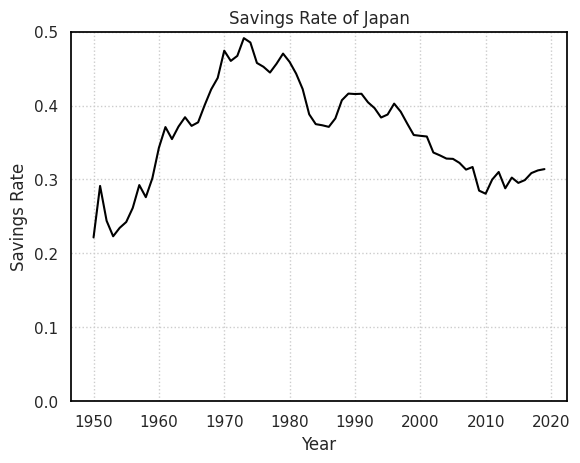

In [126]:
ax = sns.lineplot(
    data = df_2,
    x = "year",
    y = "s",
    color = "black",
)

ax.set(
    title = "Savings Rate of Japan",
    xlabel = "Year",
    ylabel = "Savings Rate",
)

ax.set_ylim(0, 0.5)

plt.show()

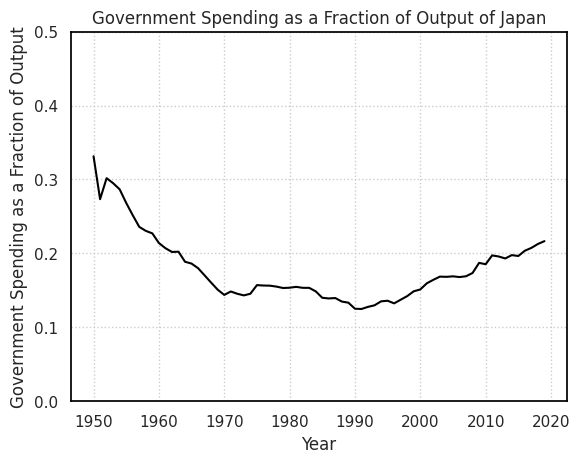

In [127]:
ax = sns.lineplot(
    data = df_2,
    x = "year",
    y = "psi",
    color = "black",
)

ax.set(
    title = "Government Spending as a Fraction of Output of Japan",
    xlabel = "Year",
    ylabel = "Government Spending as a Fraction of Output",
)

ax.set_ylim(0, 0.5)

plt.show()

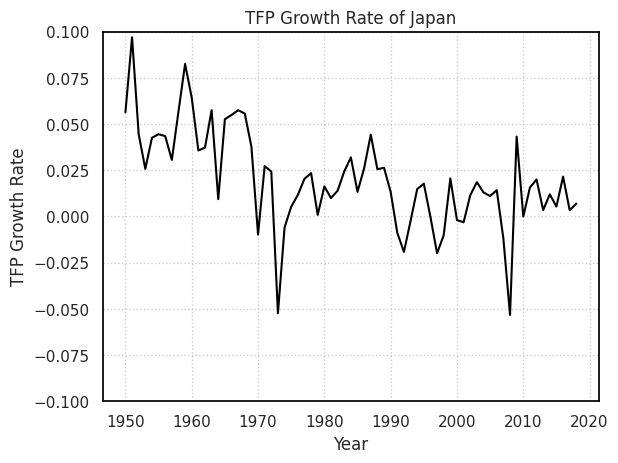

In [128]:
ax = sns.lineplot(
    data = df_2,
    x = "year",
    y = "phi",
    color = "black",
)

ax.set(
    title = "TFP Growth Rate of Japan",
    xlabel = "Year",
    ylabel = "TFP Growth Rate",
)

ax.set_ylim(-0.1, 0.1)

plt.show()

Compare to other periods, between 1950 and 1970 (i.e. after World War II and before the Bubble Economy), Japan had a high Population Growth Rate, an increasing Savings Rate, a high and declining Government Spending as a Fraction of Output, and a high TFP Growth Rate.

This indicates that Japan was recovering from World War II: People were having children as there were many casualties in World War II. People began to save more as the strict war-time economic regulations were lifted. The Japanese government was propelling the post-WWII growth.

After 1970, Japan's Population Growth Rate declines steadily and has been negative since around 2010. Savings Rate declined; it plummeted before the Bubble burst; after 2010, it has been rising slowly. Government Spending as a Fraction of Output declined during the Bubble economy and rises after the Bubble economy. TFP Growth Rate oscillates, but from a grander picture, is steady.

## Prediction of Real GDP per Capita According to the Solow Model

Based on `model_inputs` and other parameters provided by Professor Erin Cottle Hunt, we predict Japan's Real GDP per Capita according to the Solow Model. We will also compare our prediction with the real data.

The Solow Model is

\begin{align*}
Y = A\cdot K ^ \alpha \cdot N ^ {(1-\alpha)}
\end{align*}

or

\begin{align*}
y = A\cdot K ^ \alpha \cdot N ^ {-\alpha}
\end{align*}

where $Y$ is Output (Real GDP) and $y$ is Output per Capita (Real GDP per Capita).

Set some parameters to the values provided by Professor Erin Cottle Hunt.

In [129]:
alpha = 0.402 #Capital's Share in the Cobb Douglas Growth Function

delta = 0.03 #Depreciation Rate

A_1950 = 75.6 #TFP at 1950

N_1950 = 84.3 #Labor at 1950

K_1950 = 972362 #Capital at 1950

Calculate annual Total Factor Productivity ($A$) of post-WWII Japan, according to the following formula.

\begin{align*}
A_{t+1} &= A_t\cdot(1+\phi_t) \\
&= A_{1950}\cdot(1+\phi_{1950})\cdots(1+\phi_t)
\end{align*}

In R, we use a `for` loop to calculate recursion. In Python, we can calculate recursion without loops. We use operations from `pandas`.

To calculate $A_{t+1}$, we use $\phi_t$. So, in the `pandas` data frame, we match year $t$'s $(1+\phi)$ with year $t+1$'s $A$. We shift $(1+\phi)$'s row down by 1.

In [130]:
tfp_growth_rate = 1 + df_2["phi"].shift(1)

Because $A_{1950}=A_{1950}\cdot 1$. Set the `tfp_growth_rate` for the first year, `1950`, to 1.

In [131]:
tfp_growth_rate[[0]] = 1

Calculate $A_{1950}\cdot(1+\phi_{1950})\cdots(1+\phi_t)$.

In [132]:
df_2["A"] = A_1950 * tfp_growth_rate.cumprod()

Analogous to what we do above, calculate annual Labor ($N$) of post-WWII Japan, according to the following formula.

\begin{align*}
N_{t+1} &= N_t\cdot(1+x_t) \\
&= N_{1950}\cdot(1+x_{1950})\cdots(1+x_t)
\end{align*}

In [133]:
pop_growth_rate = 1 + df_2["x"].shift(1)
pop_growth_rate[[0]] = 1
df_2["N"] = N_1950 * pop_growth_rate.cumprod()

Calculate annual Capital ($K$) of post-WWII Japan recursively, according to the following formula.

\begin{align*}
K_{t+1} &= Y_t\cdot(1-\psi_t)\cdot s_t + K_t\cdot (1-\delta)\\
&= A_t\cdot K_t^{\alpha}\cdot N_t^{1-\alpha}\cdot(1-\psi_t)\cdot s_t + K_t\cdot (1-\delta)\\
&= (A_t\cdot N_t^{1-\alpha}\cdot(1-\psi_t)\cdot s_t)\cdot K_t^{\alpha} + (1-\delta) \cdot K_t
\end{align*}

In this formula, because the equation becomes very complicated if we substitute every $K_t$ with $f(K_{t-1})$, we will not use the `pandas`'s `cumprod` equation. Instead, we use `accumulate` from `itertools`.

In [134]:
from itertools import accumulate

We observe that, in the formula, the only thing that is very hard to calculate is $K$. So we isolate the coefficients for $K$. Calculate the coefficient for $K$ in the first entry.

In [135]:
coef_K = df_2["A"] * (df_2["N"] ** (1-alpha)) * (1 - df_2["psi"]) * df_2["s"]

Define $K_{t+1}=f(K_t)$.

In [136]:
def update_K(K, coef_K):
  return coef_K * (K ** alpha) + (1 - delta) * K

`accumulate` is essentially a loop function. Starting from the `initial` value `K_1950`, for every step, `update_K` takes `K` as the first parameter and `coef_K` as the second parameter, and return a series `K`.

In [137]:
K = np.fromiter(accumulate(coef_K, update_K, initial = K_1950), dtype=float)

Remove the last entry of `K` because we looped to $t+1 = 2023+1 = 2024$, rather than 2023.

Save `K` to `df_2`.

In [138]:
df_2["K"] = K[:-1]

### Prediction of Output per Capita

Calculate annual Output per Capita (Real GDP per Capita, $y$) of post-WWII Japan, according to the formula for the Solow Model.

In [139]:
df_2["y"] = df_2["A"] * (df_2["K"] ** alpha) * (df_2["N"] ** (-alpha))

Plot actual and predicted Real GDP per Capita of Japan.

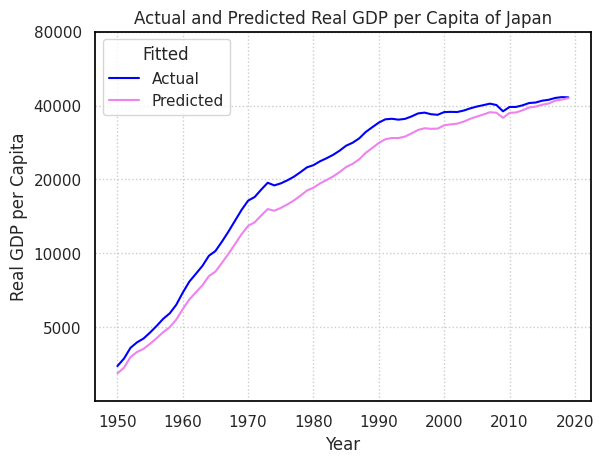

In [140]:
df_2_rgdpc_solow_long = df_2.melt(
    id_vars = ["year"],
    value_vars = ["rgdpc_jpa", "y"],
    var_name = "Fitted",
    value_name ="rgdpc",
)

df_2_rgdpc_solow_long["Fitted"] = df_2_rgdpc_solow_long["Fitted"].map({"rgdpc_jpa": "Actual", "y": "Predicted"})

ax = sns.lineplot(
    data = df_2_rgdpc_solow_long,
    x = "year",
    y = "rgdpc",
    hue = "Fitted",
    palette = {"Actual": "blue", "Predicted": "violet"}
)

ax.set(
    title = "Actual and Predicted Real GDP per Capita of Japan",
    xlabel = "Year",
    ylabel = "Real GDP per Capita",
)

ax.set_yscale("log")
ax.set_ylim(2500, 80000)
ax.set_yticks([5000, 10000, 20000, 40000, 80000])
ax.get_yaxis().set_major_formatter(ticker.ScalarFormatter())

plt.show()

### Prediction of Output per Capita Growth Rate

Calculate the actual and predicted annual growth rate of Real GDP per Capita.

In [141]:
actual_y = df_2["rgdpc_jpa"].shift(1)

predicted_y = df_2["y"].shift(1)

df_2["y_growth_actual"] = df_2["rgdpc_jpa"]/actual_y - 1

df_2["y_growth_predicted"] = df_2["y"]/predicted_y - 1

Plot them.

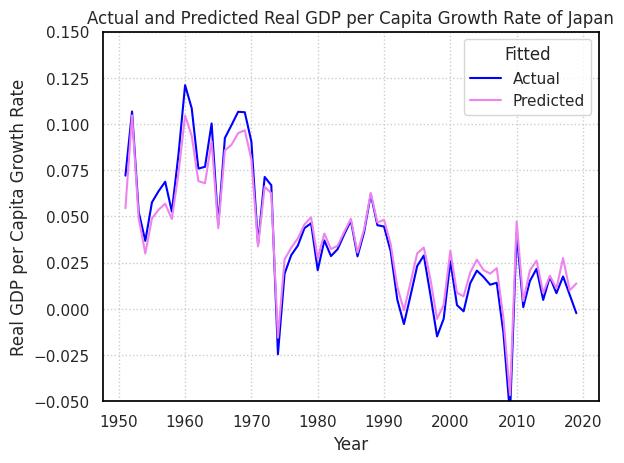

In [142]:
df_2_rgdpc_growth_solow_long = df_2.melt(
    id_vars = ["year"],
    value_vars = ["y_growth_actual", "y_growth_predicted"],
    var_name = "Fitted",
    value_name = "rgdpc_growth",
)

df_2_rgdpc_growth_solow_long["Fitted"] = df_2_rgdpc_growth_solow_long["Fitted"].map({"y_growth_actual": "Actual", "y_growth_predicted": "Predicted"})

ax = sns.lineplot(
    data = df_2_rgdpc_growth_solow_long,
    x = "year",
    y = "rgdpc_growth",
    hue = "Fitted",
    palette = {"Actual": "blue", "Predicted": "violet"}
)

ax.set(
    title = "Actual and Predicted Real GDP per Capita Growth Rate of Japan",
    xlabel = "Year",
    ylabel = "Real GDP per Capita Growth Rate",
)

ax.set_ylim(-0.05, 0.15)

plt.show()

## Conclusion

Compare the two plots above, the Solow Model predicts Japan's Output trends quite accurately based on the parameters Professor Erin Cottle Hunt provided.

# Section III. Counterfactual Solow Models of Japan Post World War II Economic Growth

In this section, we explore which factor mainly influences the exact trend (i.e. the kinks, the slope of each segment) of (Japan) economic growth.

To explore causality, we develop and look at several counterfactuals. When we change the value of a factor (for instance, hold this factor constant) and predict the growth trend, if the growth trend is very similar to the actual growth trend, then (changes in) this factor does not affect growth trend much.

On the other hand, if we change the value of a factor (for instance, hold this factor constant) and the prediction differs significantly from the actual, this factor affects growth trend very much.

We do not do tests of significance. We evaluate the predictions visually.

## Counterfactual Models

Calculate the mean values of $x$, $s$, $\psi$, and $\phi$.

In [143]:
x_hat = df_2["x"].mean()
s_hat = df_2["s"].mean()
psi_hat = df_2["psi"].mean()
phi_hat = df_2["phi"].mean()

Calculate Real GDP per Capita, holding Population Growth Rate at mean value. Among the parameters of the Solow Model, $K$ and $N$ are affected by the counterfactual.

The end years of the data series in `df_2` are 2019, because `model_inputs`, provided by Professor Erin Cottle Hunt, has data that end in 2019.

In [144]:
pop_geometric_series = pd.Series(N_1950 * ((1+x_hat)) ** np.arange(2019-1950+1))

coef_K_counterfactual_1 = df_2["A"] * (pop_geometric_series ** (1-alpha)) * (1 - df_2["psi"]) * df_2["s"]

K_counterfactual_1 = np.fromiter(accumulate(coef_K_counterfactual_1, update_K, initial = K_1950), dtype=float)

df_2["K_counterfactual_1"] = K_counterfactual_1[:-1]

df_2["y_counterfactual_1"] = df_2["A"] * (df_2["K_counterfactual_1"] ** alpha) * (pop_geometric_series ** (-alpha))

Calculate Real GDP per Capita, holding Savings Rate at mean value. Among the parameters of the Solow Model, $K$ is affected by the counterfactual.

In [145]:
coef_K_counterfactual_2 = df_2["A"] * (df_2["N"] ** (1-alpha)) * (1 - df_2["psi"]) * s_hat

K_counterfactual_2 = np.fromiter(accumulate(coef_K_counterfactual_2, update_K, initial = K_1950), dtype=float)

df_2["K_counterfactual_2"] =K_counterfactual_2[:-1]

df_2["y_counterfactual_2"] = df_2["A"] * (df_2["K_counterfactual_2"] ** alpha) * (df_2["N"] ** (-alpha))

Calculate Real GDP per Capita, holding Government Spending as a Fraction of Output at mean value. Among the parameters of the Solow Model, $K$ is affected by the counterfactual.

In [146]:
coef_K_counterfactual_3 = df_2["A"] * (df_2["N"] ** (1-alpha)) * (1 - psi_hat) * df_2["s"]

K_counterfactual_3 = np.fromiter(accumulate(coef_K_counterfactual_3, update_K, initial = K_1950), dtype=float)

df_2["K_counterfactual_3"] =K_counterfactual_3[:-1]

df_2["y_counterfactual_3"] = df_2["A"] * (df_2["K_counterfactual_3"] ** alpha) * (df_2["N"] ** (-alpha))

Calculate Real GDP per Capita, holding TFP Growth Rate at mean value. Among the parameters of the Solow Model, $K$ and $A$ are affected by the counterfactual.

In [147]:
tfp_geometric_series = pd.Series(A_1950 * ((1+phi_hat)) ** np.arange(2019-1950+1))

coef_K_counterfactual_4 = tfp_geometric_series * (df_2["N"] ** (1-alpha)) * (1 - df_2["psi"]) * df_2["s"]

K_counterfactual_4 = np.fromiter(accumulate(coef_K_counterfactual_4, update_K, initial = K_1950), dtype=float)

df_2["K_counterfactual_4"] =K_counterfactual_4[:-1]

df_2["y_counterfactual_4"] = tfp_geometric_series * (df_2["K_counterfactual_4"] ** alpha) * (df_2["N"] ** (-alpha))

## Counterfactual Plots

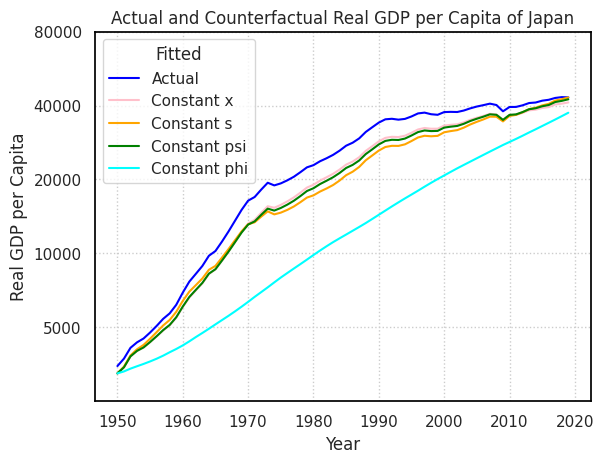

In [148]:
df_2_rgdpc_counterfactual_long = df_2.melt(
    id_vars = ["year"],
    value_vars = ["rgdpc_jpa", "y_counterfactual_1", "y_counterfactual_2", "y_counterfactual_3", "y_counterfactual_4"],
    var_name = "Fitted",
    value_name ="rgdpc",
)

df_2_rgdpc_counterfactual_long["Fitted"] = df_2_rgdpc_counterfactual_long["Fitted"].map({"rgdpc_jpa": "Actual", "y_counterfactual_1": "Constant x", "y_counterfactual_2": "Constant s", "y_counterfactual_3": "Constant psi", "y_counterfactual_4": "Constant phi"})

ax = sns.lineplot(
    data = df_2_rgdpc_counterfactual_long,
    x = "year",
    y = "rgdpc",
    hue = "Fitted",
    palette = {"Actual": "blue", "Constant x": "pink", "Constant s": "orange", "Constant psi": "green", "Constant phi": "cyan"}
)

ax.set(
    title = "Actual and Counterfactual Real GDP per Capita of Japan",
    xlabel = "Year",
    ylabel = "Real GDP per Capita",
)

ax.set_yscale("log")
ax.set_ylim(2500, 80000)
ax.set_yticks([5000, 10000, 20000, 40000, 80000])
ax.get_yaxis().set_major_formatter(ticker.ScalarFormatter())


According to the plot above, if we hold TFP Growth Rate ($\phi$) constant, the prediction differs very much from the actual. Therefore, among Population Growth Rate ($x$), Savings Rate ($s$), Government Spending as Fraction of Output ($\psi$), and TFP Growth Rate ($\phi$), $\phi$ is most accountable for the exact shape of Real GDP growth trend.

In other words, Total Factor Productivity ($A$) mainly influences the exact trend of (Japan) economic growth.

## Holding All Except $\phi$ constant

We also look at what the growth trend looks like, if we hold $x$, $s$, and $\psi$ constant and let $\phi$ be the only varying variable that influences Output.

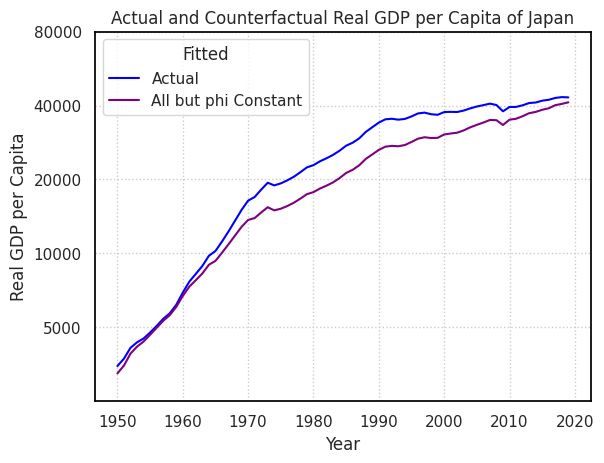

In [149]:
coef_K_counterfactual_5 = df_2["A"] * (pop_geometric_series ** (1-alpha)) * (1 - psi_hat) * s_hat

K_counterfactual_5 = np.fromiter(accumulate(coef_K_counterfactual_5, update_K, initial = K_1950), dtype=float)

df_2["K_counterfactual_5"] = K_counterfactual_5[:-1]

df_2["y_counterfactual_5"] = df_2["A"] * (df_2["K_counterfactual_5"] ** alpha) * (pop_geometric_series ** (-alpha))

df_2_rgdpc_counterfactual_long_2 = df_2.melt(
    id_vars = ["year"],
    value_vars = ["rgdpc_jpa", "y_counterfactual_5"],
    var_name = "Fitted",
    value_name ="rgdpc",
)

df_2_rgdpc_counterfactual_long_2["Fitted"] = df_2_rgdpc_counterfactual_long_2["Fitted"].map({"rgdpc_jpa": "Actual", "y_counterfactual_5": "All but phi Constant"})

ax = sns.lineplot(
    data = df_2_rgdpc_counterfactual_long_2,
    x = "year",
    y = "rgdpc",
    hue = "Fitted",
    palette = {"Actual": "blue", "All but phi Constant": "purple"}
)

ax.set(
    title = "Actual and Counterfactual Real GDP per Capita of Japan",
    xlabel = "Year",
    ylabel = "Real GDP per Capita",
)

ax.set_yscale("log")
ax.set_ylim(2500, 80000)
ax.set_yticks([5000, 10000, 20000, 40000, 80000])
ax.get_yaxis().set_major_formatter(ticker.ScalarFormatter())

This verifies our conclusion that Total Factor Productivity ( 𝐴 ) mainly influences the exact trend of (Japan) economic growth.

# Section IV. What Post-1970 TFP Growth Rate Japan Needs to Have to Make Its Real GDP per Capita Converge to That of USA

Since 1970, Japan experienced the Bubble Economy and post-Bubble-Economy. Its Real GDP per Capita growth slows down.

Because TFP Growth Rate mainly influences the exact trend of (Japan), we will look at what post-1970 $\phi$ should be for Japan's Real GDP per Capita to converge to USA's Real GDP per Capita.

Because we have to solve the recursive equation $y=f(\phi)$, and because it is in general hard to solve recursive equations in R, we solve the equation only in Python.

We do not solve for a series of $\phi$, as we do not know how $\phi$ is calculated exogenously outside the Solow Model.

We solve for a single, fixed post-1970 $\phi$.

We use a shooting and binary search method to solve for $\phi$.


For every choice of $\phi$, we simulate a path of $y$ and compare it to that of the actual $y$.

Use a while loop to shoot path of $y$.
1. For every new run, clear all values of $y$.
2. Guess for $\phi$ by taking average of the upper and lower bound.
3. Fill in paths of $A$, $K$, and $y$.
4. Check for convergence. While loop stops when the difference between the actual $y$ and the simulated $y$ is small, and when the slope of the actual $y$ and the simulatedd $y$ are about identical.
5. Update the initial guess by resetting the upper or lower bound.

We choose our initial lower bound to be 0 and our initial upper bound to be 1.

In [150]:
A_1970 = df_2["A"][1970-1950]

K_1970 = df_2["K"][1970-1950]

phi_lower = 0

phi_upper = 1

y_usa_2019_growth = (df_2["rgdpc_usa"][2019-1950]-df_2["rgdpc_usa"][2018-1950])/(df_2["rgdpc_usa"][2018-1950])

y_jpa_2019_growth = (df_2["rgdpc_jpa"][2019-1950]-df_2["rgdpc_jpa"][2018-1950])/(df_2["rgdpc_jpa"][2018-1950])

diff_growth = y_usa_2019_growth - y_jpa_2019_growth

diff_output = df_2["rgdpc_usa"][2019-1950]-df_2["y"][2019-1950]

N_simulated = df_2.iloc[(1970-1950):(2019-1950+1), df_2.columns.get_loc("N")].reset_index(drop=True)

psi_simulated = df_2.iloc[(1970-1950):(2019-1950+1), df_2.columns.get_loc("psi")].reset_index(drop=True)

s_simulated = df_2.iloc[(1970-1950):(2019-1950+1), df_2.columns.get_loc("s")].reset_index(drop=True)

while abs(diff_growth) > 10 ** (-6) and abs(diff_output) > 1000:
    phi_guess = (phi_lower + phi_upper)/2

    A_simulated = pd.Series(A_1970 * ((1+phi_guess)) ** np.arange(2019-1970+1))
    coef_K = A_simulated * (N_simulated ** (1-alpha)) * (1 - psi_simulated) * s_simulated
    K_simulated = np.fromiter(accumulate(coef_K, update_K, initial = K_1970), dtype=float)
    K_simulated = K_simulated[:-1]

    y_simulated = A_simulated * (K_simulated ** alpha) * (N_simulated ** (-alpha))

    y_simulated_2019_growth = (y_simulated[2019-1970] - y_simulated[2018-1970])/y_simulated[2018-1970]

    diff_growth = y_usa_2019_growth - y_simulated_2019_growth

    diff_output = df_2["rgdpc_usa"][2019-1950] - y_simulated[2019-1970]

    if (y_simulated_2019_growth >= y_usa_2019_growth) and (diff_output <= 0):
        phi_upper = phi_guess
    elif (y_simulated_2019_growth > y_usa_2019_growth) and (diff_output > 0):
        phi_lower = phi_guess
    elif (y_simulated_2019_growth >= y_usa_2019_growth) and (diff_output <= 0):
        phi_upper = phi_guess
    else:
        phi_lower = phi_guess

Print the solved $\phi$.

In [151]:
print(phi_guess)

0.015380859375


Plot the simulation.

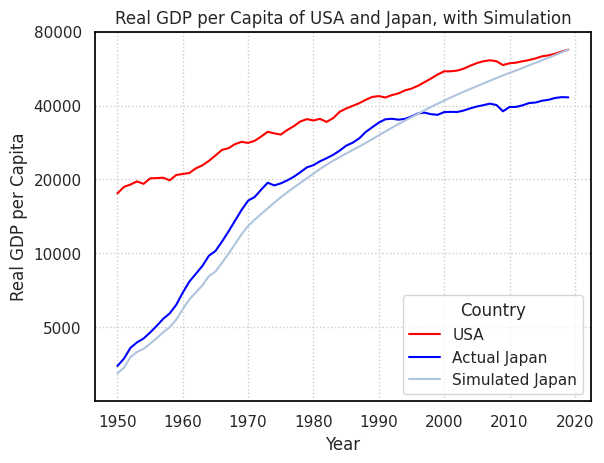

In [152]:
df_2["y_simulated"] = np.zeros(2019-1950+1)

df_2.iloc[0:(1970-1950), df_2.columns.get_loc("y_simulated")] = df_2.iloc[0:(1970-1950), df_2.columns.get_loc("y")]
df_2.iloc[(1970-1950):(2019-1950+1), df_2.columns.get_loc("y_simulated")] = y_simulated.values

df_2_simulated_long = df_2.melt(
    id_vars = ["year"],
    value_vars = ["rgdpc_usa", "rgdpc_jpa", "y_simulated"],
    var_name = "Country",
    value_name = "rgdpc",
)

df_2_simulated_long["Country"] = df_2_simulated_long["Country"].map({"rgdpc_usa": "USA", "rgdpc_jpa": "Actual Japan", "y_simulated": "Simulated Japan"})

ax = sns.lineplot(
    data = df_2_simulated_long,
    x = "year",
    y = "rgdpc",
    hue = "Country",
    palette = {"USA": "red", "Actual Japan": "blue", "Simulated Japan": "lightsteelblue"}
)

ax.set(
    title = "Real GDP per Capita of USA and Japan, with Simulation",
    xlabel = "Year",
    ylabel = "Real GDP per Capita",
)

ax.set_yscale("log")
ax.set_ylim(2500, 80000)
ax.set_yticks([5000, 10000, 20000, 40000, 80000])
ax.get_yaxis().set_major_formatter(ticker.ScalarFormatter())

plt.show()